# TMDB Movie Data Analysis (PySpark)

#### 1. Setup

Importing modules and starting the Spark session (autoreload picks up edits to `src/*.py` without restarting the kernel).

In [3]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib.pyplot as plt

from src import config
from src.spark_session import get_spark_session
from src.ingestion import ensure_raw_cache
from src.preprocessing import preprocess
from src import analysis
from src import visualization

spark = get_spark_session()
config.check_token()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[2026-08-09 17:47:31] [INFO] [spark_session]: SparkSession ready: app=tmdb-movie-analysis master=local[*] shuffle.partitions=4 warehouse=/home/jovyan/work/data/spark-warehouse
TMDB token loaded successfully.


True

#### 2. Fetching movie data from the API (cache-first)

In [4]:
records = ensure_raw_cache()
print(f"Cached {len(records)} movie record(s).")

[2026-08-09 17:47:37] [INFO] [ingestion]: No cache found at /home/jovyan/work/data/raw/movies_raw.csv -- fetching all 19 movie(s).
[2026-08-09 17:47:40] [WARNING] [ingestion]: Skipping id 0 (HTTP 404)
[2026-08-09 17:47:41] [INFO] [ingestion]: Fetched 'Avengers: Endgame' (id 299534)
[2026-08-09 17:47:41] [INFO] [ingestion]: Fetched 'Avatar' (id 19995)
[2026-08-09 17:47:42] [INFO] [ingestion]: Fetched 'Star Wars: The Force Awakens' (id 140607)
[2026-08-09 17:47:43] [INFO] [ingestion]: Fetched 'Avengers: Infinity War' (id 299536)
[2026-08-09 17:47:44] [INFO] [ingestion]: Fetched 'Titanic' (id 597)
[2026-08-09 17:47:45] [INFO] [ingestion]: Fetched 'Jurassic World' (id 135397)
[2026-08-09 17:47:45] [INFO] [ingestion]: Fetched 'The Lion King' (id 420818)
[2026-08-09 17:47:46] [INFO] [ingestion]: Fetched 'The Avengers' (id 24428)
[2026-08-09 17:47:47] [INFO] [ingestion]: Fetched 'Furious 7' (id 168259)
[2026-08-09 17:47:48] [INFO] [ingestion]: Fetched 'Avengers: Age of Ultron' (id 99861)
[202

Cache-first in action: running ingestion again should make **zero** TMDB API calls this time. Watch the logged output just above this cell's result for the "Cache hit: ... no API calls made" line (id `0` is the brief's own intentionally-invalid placeholder, so it's the one exception that always retries and 404s -- expected, and harmless).

In [5]:
records_again = ensure_raw_cache()
print(f"Still {len(records_again)} record(s) -- no new movies were fetched.")

[2026-08-09 17:48:00] [INFO] [ingestion]: Partial cache at /home/jovyan/work/data/raw/movies_raw.csv: 18/19 id(s) already present, fetching 1 missing id(s): [0]
[2026-08-09 17:48:01] [WARNING] [ingestion]: Skipping id 0 (HTTP 404)
[2026-08-09 17:48:01] [WARNING] [ingestion]: Could not fetch any of the 1 missing id(s) [0] -- keeping the 18 already-cached record(s) as-is (expected for ids TMDB doesn't recognize, e.g. the brief's own id 0).
Still 18 record(s) -- no new movies were fetched.


#### 3. Data cleaning & preprocessing

In [6]:
# preprocess() runs the full clean pipeline and writes data/clean/movies_clean.csv
# as part of its own execution -- unlike the pandas original, there's no separate
# "save the clean dataset" step needed later in this notebook.
df = preprocess(spark)
df.show(5)

[2026-08-09 17:48:20] [INFO] [preprocessing]: Loaded 18 raw rows from /home/jovyan/work/data/raw/movies_raw.csv
[2026-08-09 17:48:25] [INFO] [preprocessing]: clean_rows: 18 -> 18 (dedup) -> 18 (>=10 non-null) -> 18 (Released only)
[2026-08-09 17:48:28] [INFO] [preprocessing]: Wrote clean dataset to /home/jovyan/work/data/clean/movies_clean.csv
[2026-08-09 17:48:28] [INFO] [preprocessing]: Clean dataset: 18 movies x 22 columns.
+-----+--------------------+--------------------+------------+--------------------+---------------------+-----------------+-----------+------------+--------------------+--------------------+----------+------------+----------+-------+--------------------+--------------------+--------------------+--------------------+---------+-------------+---------+
|   id|               title|             tagline|release_date|              genres|belongs_to_collection|original_language|budget_musd|revenue_musd|production_companies|production_countries|vote_count|vote_average|pop

In [7]:
df.printSchema()
print(f"Shape: {df.count()} rows x {len(df.columns)} columns")

root
 |-- id: long (nullable = true)
 |-- title: string (nullable = true)
 |-- tagline: string (nullable = true)
 |-- release_date: date (nullable = true)
 |-- genres: string (nullable = true)
 |-- belongs_to_collection: string (nullable = true)
 |-- original_language: string (nullable = true)
 |-- budget_musd: double (nullable = true)
 |-- revenue_musd: double (nullable = true)
 |-- production_companies: string (nullable = true)
 |-- production_countries: string (nullable = true)
 |-- vote_count: long (nullable = true)
 |-- vote_average: double (nullable = true)
 |-- popularity: double (nullable = true)
 |-- runtime: double (nullable = true)
 |-- overview: string (nullable = true)
 |-- spoken_languages: string (nullable = true)
 |-- poster_path: string (nullable = true)
 |-- cast: string (nullable = true)
 |-- cast_size: integer (nullable = true)
 |-- director: string (nullable = true)
 |-- crew_size: integer (nullable = true)

Shape: 18 rows x 22 columns


#### 4. KPIs & analysis

##### 4.1 Best/worst performing movies

In [8]:
print("Highest Revenue"); analysis.highest_revenue(df).show(truncate=False)
print("Highest Budget"); analysis.highest_budget(df).show(truncate=False)
print("Highest Profit (revenue - budget)"); analysis.highest_profit(df).show(truncate=False)
print("Lowest Profit"); analysis.lowest_profit(df).show(truncate=False)
print("Highest ROI (budget >= 10M)"); analysis.highest_roi(df).show(truncate=False)
print("Lowest ROI (budget >= 10M)"); analysis.lowest_roi(df).show(truncate=False)

Highest Revenue
[2026-08-09 17:49:12] [INFO] [analysis]: rank_movies(by=revenue_musd, ascending=False, n=5): 5 row(s)
+----------------------------+------------+
|title                       |revenue_musd|
+----------------------------+------------+
|Avatar                      |2923.706026 |
|Avengers: Endgame           |2799.4391   |
|Titanic                     |2264.162353 |
|Star Wars: The Force Awakens|2068.223624 |
|Avengers: Infinity War      |2052.415039 |
+----------------------------+------------+

Highest Budget
[2026-08-09 17:49:13] [INFO] [analysis]: rank_movies(by=budget_musd, ascending=False, n=5): 5 row(s)
+----------------------------+-----------+
|title                       |budget_musd|
+----------------------------+-----------+
|Avengers: Endgame           |356.0      |
|Star Wars: The Last Jedi    |300.0      |
|Avengers: Infinity War      |300.0      |
|The Lion King               |260.0      |
|Star Wars: The Force Awakens|245.0      |
+------------------------

In [9]:
print("Most Voted"); analysis.most_voted(df).show(truncate=False)
print("Highest Rated (>= 10 votes)"); analysis.highest_rated(df).show(truncate=False)
print("Lowest Rated (>= 10 votes)"); analysis.lowest_rated(df).show(truncate=False)
print("Most Popular"); analysis.most_popular(df).show(truncate=False)

Most Voted
[2026-08-09 17:49:23] [INFO] [analysis]: rank_movies(by=vote_count, ascending=False, n=5): 5 row(s)
+----------------------+----------+
|title                 |vote_count|
+----------------------+----------+
|The Avengers          |39119     |
|Avatar                |34402     |
|Avengers: Infinity War|32509     |
|Avengers: Endgame     |28248     |
|Titanic               |27497     |
+----------------------+----------+

Highest Rated (>= 10 votes)
[2026-08-09 17:49:24] [INFO] [analysis]: rank_movies(by=vote_average, ascending=False, n=5): 5 row(s)
+--------------------------------------------+------------+----------+
|title                                       |vote_average|vote_count|
+--------------------------------------------+------------+----------+
|Avengers: Infinity War                      |8.24        |32509     |
|Avengers: Endgame                           |8.239       |28248     |
|Harry Potter and the Deathly Hallows: Part 2|8.08        |22242     |
|The Ave

##### 4.2 Advanced search queries

- **Search 1:** best-rated *Science-Fiction Action* movies starring **Bruce Willis** (by rating, high → low)
- **Search 2:** movies starring **Uma Thurman**, directed by **Quentin Tarantino** (by runtime, short → long)

Both are expected to return zero rows against this particular 18-movie sample (all major franchise blockbusters) -- confirmed correct against the pandas reference implementation, not a bug.

In [10]:
print("Search 1 - Sci-Fi Action, Bruce Willis:")
analysis.search_scifi_action_bruce_willis(df).show(truncate=False)

print("Search 2 - Uma Thurman + Quentin Tarantino:")
analysis.search_thurman_tarantino(df).show(truncate=False)

Search 1 - Sci-Fi Action, Bruce Willis:
[2026-08-09 17:49:30] [INFO] [analysis]: search_movies(genres=['Science Fiction', 'Action'], cast=Bruce Willis, director=None): 0 row(s)
+-----+------------+------+----+
|title|vote_average|genres|cast|
+-----+------------+------+----+
+-----+------------+------+----+

Search 2 - Uma Thurman + Quentin Tarantino:
[2026-08-09 17:49:31] [INFO] [analysis]: search_movies(genres=None, cast=Uma Thurman, director=Quentin Tarantino): 0 row(s)
+-----+-------+--------+----+
|title|runtime|director|cast|
+-----+-------+--------+----+
+-----+-------+--------+----+



##### 4.3 Franchise vs. Standalone movies

In [11]:
analysis.franchise_vs_standalone(df).show(truncate=False)

+------------+------------------+-----------------+-----------+------------------+-----------+
|is_franchise|mean_revenue      |median_roi       |mean_budget|mean_popularity   |mean_rating|
+------------+------------------+-----------------+-----------+------------------+-----------+
|Franchise   |1682.7752161249998|7.786117185822869|218.0      |39.110437499999996|7.3931875  |
|Standalone  |1765.1391585000001|9.61701827       |180.0      |28.822250000000004|7.4335     |
+------------+------------------+-----------------+-----------+------------------+-----------+



##### 4.4 Most successful franchises

In [12]:
analysis.franchise_summary(df).show(truncate=False)

+------------------------+----------+------------+-----------+------------------+------------------+------------------+
|belongs_to_collection   |num_movies|total_budget|mean_budget|total_revenue     |mean_revenue      |mean_rating       |
+------------------------+----------+------------+-----------+------------------+------------------+------------------+
|The Avengers Collection |4         |1111.0      |277.75     |7776.073348       |1944.018337       |7.954750000000001 |
|Star Wars Collection    |2         |545.0       |272.5      |3402.63133        |1701.315665       |6.9719999999999995|
|Jurassic Park Collection|2         |320.0       |160.0      |2982.0064810000003|1491.0032405000002|6.617             |
|Frozen Collection       |2         |300.0       |150.0      |2727.9024849999996|1363.9512424999998|7.2379999999999995|
+------------------------+----------+------------+-----------+------------------+------------------+------------------+



##### 4.5 Most successful directors

In [13]:
analysis.director_summary(df).show(20, truncate=False)

+---------------+----------+------------------+------------------+
|director       |num_movies|total_revenue     |mean_rating       |
+---------------+----------+------------------+------------------+
|James Cameron  |2         |5187.868379       |7.7545            |
|Joe Russo      |2         |4851.854139       |8.2395            |
|Anthony Russo  |2         |4851.854139       |8.2395            |
|Joss Whedon    |2         |2924.219209       |7.67              |
|Chris Buck     |2         |2727.9024849999996|7.2379999999999995|
|Jennifer Lee   |2         |2727.9024849999996|7.2379999999999995|
|J.J. Abrams    |1         |2068.223624       |7.2               |
|Colin Trevorrow|1         |1671.537444       |6.703             |
|Jon Favreau    |1         |1662.020819       |7.095             |
|James Wan      |1         |1515.4            |7.215             |
|Ryan Coogler   |1         |1349.926083       |7.365             |
|David Yates    |1         |1341.511219       |8.08           

#### 5. Visualizations

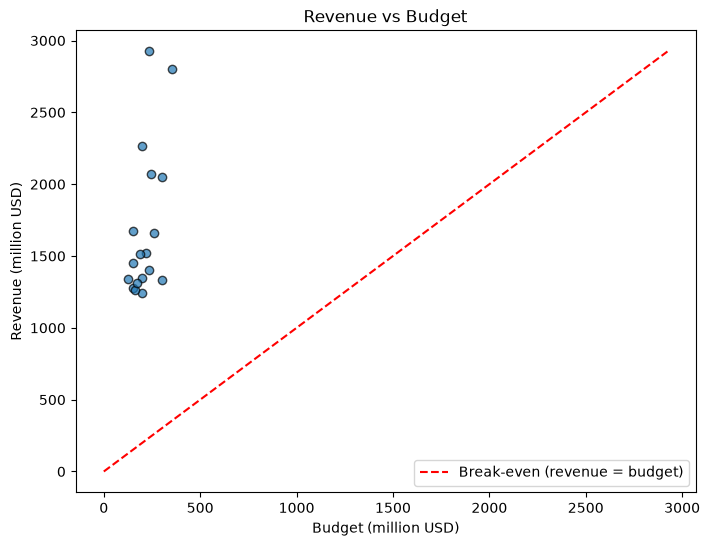

In [14]:
visualization.revenue_vs_budget(df)
plt.show()

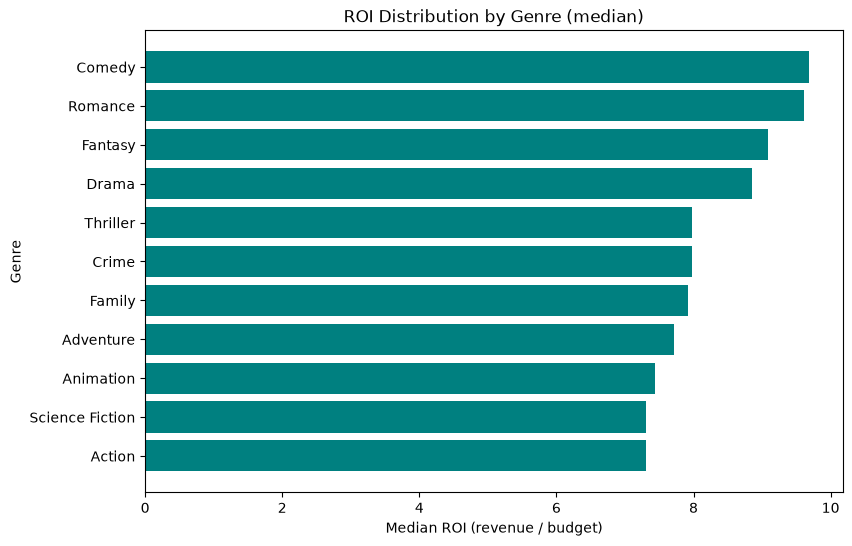

In [15]:
visualization.roi_by_genre(df)
plt.show()

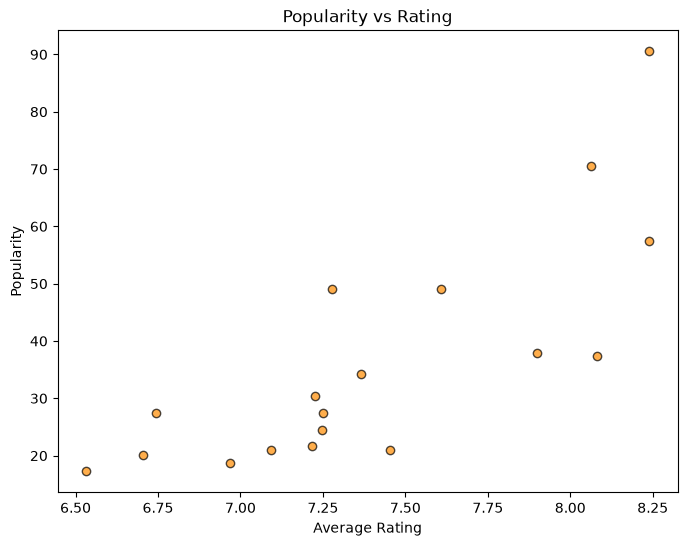

In [14]:
visualization.popularity_vs_rating(df)
plt.show()

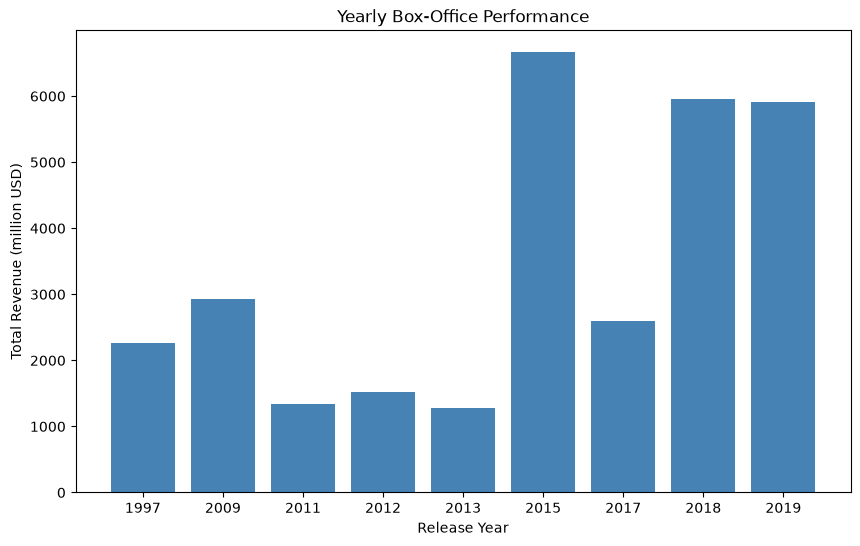

In [16]:
visualization.yearly_box_office(df)
plt.show()

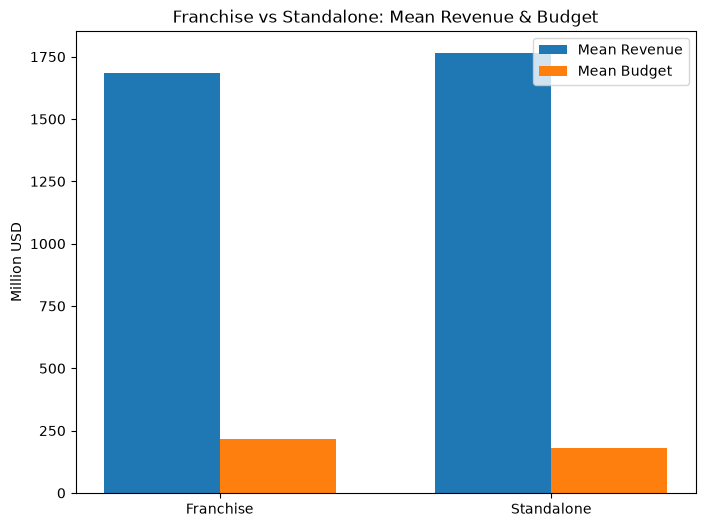

In [17]:
visualization.franchise_vs_standalone_plot(df)
plt.show()

Save all five charts to `images/` with deterministic numbered filenames (closing a gap the pandas original left open -- it never called `savefig`, so its `images/` PNGs were exported by hand).

In [18]:
chart_paths = visualization.generate_all_charts(df)
print("Saved charts:")
for path in chart_paths:
    print(f"  {path}")

[2026-08-09 17:50:23] [INFO] [visualization]: Wrote 5 chart(s) to /home/jovyan/work/images
Saved charts:
  /home/jovyan/work/images/01-revenue-vs-budget.png
  /home/jovyan/work/images/02-roi-by-genre.png
  /home/jovyan/work/images/03-popularity-vs-rating.png
  /home/jovyan/work/images/04-yearly-box-office.png
  /home/jovyan/work/images/05-franchise-vs-standalone.png


#### 6. Stop the Spark session

In [19]:
spark.stop()
print("Spark session stopped.")

Spark session stopped.
